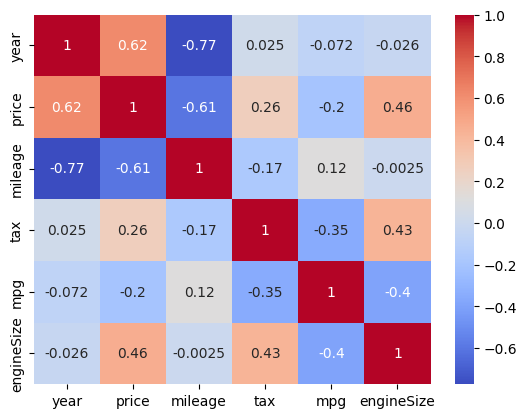

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Načtení dat
df = pd.read_csv('bmw.csv')

# Zajímá nás jen korelace číselných sloupců (Cena, Rok, Motor, atd.)
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

# Zobrazení heatmapy
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
import pandas as pd
import duckdb

# 1. NAČTENÍ DAT
print("Načítám data z CSV...")
df = pd.read_csv('bmw.csv')

# 2. TVORBA DIMENZÍ (Odstranění duplicit a vytvoření ID)

# Dimenze 1: Model auta
dim_model = df[['model']].drop_duplicates().reset_index(drop=True)
dim_model['model_id'] = dim_model.index + 1

# Dimenze 2: Vlastnosti (Palivo a Převodovka)
dim_feature = df[['transmission', 'fuelType']].drop_duplicates().reset_index(drop=True)
dim_feature['feature_id'] = dim_feature.index + 1

# Dimenze 3: Čas (Rok)
dim_time = df[['year']].drop_duplicates().reset_index(drop=True)
dim_time['time_id'] = dim_time.index + 1
# Přidáme odvozený sloupec pro bohatší OLAP (např. desetiletí), ať paní učitelka vidí snahu
dim_time['decade'] = (dim_time['year'] // 10) * 10

print("Dimenze vytvořeny.")

# 3. TVORBA TABULKY FAKTŮ
print("Vytvářím tabulku faktů...")
# Připojíme (JOIN) IDčka z dimenzí zpět k hlavním datům
fact_sales = df.merge(dim_model, on='model') \
               .merge(dim_feature, on=['transmission', 'fuelType']) \
               .merge(dim_time, on='year')

# Vybereme jen IDčka dimenzí a faktické (číselné) hodnoty
fact_sales = fact_sales[['model_id', 'feature_id', 'time_id',
                         'price', 'mileage', 'tax', 'mpg', 'engineSize']]

# Přidáme primární klíč pro samotný prodej
fact_sales.insert(0, 'sale_id', range(1, 1 + len(fact_sales)))

print(f"Tabulka faktů hotova. Celkem záznamů: {len(fact_sales)}")

# 4. ULOŽENÍ DO DUCKDB
print("Ukládám do databáze DuckDB...")
# Otevřeme/vytvoříme souborovou databázi
con = duckdb.connect('bmw_dwh.duckdb')

# Vytvoření a naplnění tabulek v databázi z Pandas DataFrame
con.execute("CREATE OR REPLACE TABLE Dim_Model AS SELECT * FROM dim_model")
con.execute("CREATE OR REPLACE TABLE Dim_Feature AS SELECT * FROM dim_feature")
con.execute("CREATE OR REPLACE TABLE Dim_Time AS SELECT * FROM dim_time")
con.execute("CREATE OR REPLACE TABLE Fact_Sales AS SELECT * FROM fact_sales")

# Uzavření spojení
con.close()
print("Hotovo! Soubor 'bmw_dwh.duckdb' je připraven pro DataGrip.")

Načítám data z CSV...


FileNotFoundError: [Errno 2] No such file or directory: 'bmw_data.csv'